In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Exact displacement and strain
def u_exact(x):
    return x**3

def strain_exact(x):
    return 3*x**2


In [2]:
def fem_solution(n_elements, n_plot=200):
    """
    Compute the FE displacement and strain for a 1D bar
    with linear two-node elements.

    Parameters
    ----------
    n_elements : int
        Number of linear elements.
    n_plot : int
        Number of plotting points per element.

    Returns
    -------
    x_nodes : ndarray
        Nodal coordinates.
    d : ndarray
        Nodal displacements.
    x_all : ndarray
        Coordinates for the FE displacement plot.
    u_fe : ndarray
        FE displacement values.
    strain_x : ndarray
        Coordinates for the FE strain plot.
    strain_fe : ndarray
        FE strain values.
    """

    # 1. Generate mesh
    x_nodes = np.linspace(0.0, 1.0, n_elements + 1)

    # Nodal displacements from exact solution
    d = u_exact(x_nodes)

    # Storage for FE solution
    x_all = []
    u_fe = []
    strain_x = []
    strain_fe = []

    # 2. Loop over elements
    for e in range(n_elements):

        # Element local nodal coordinates
        x1 = x_nodes[e]
        x2 = x_nodes[e + 1]

        # Element nodal displacements
        d1 = d[e]
        d2 = d[e + 1]

        # Element length
        h = x2 - x1

        # Local plotting coordinates
        x = np.linspace(x1, x2, n_plot)

        # Linear shape functions
        N1 = (x2 - x) / h
        N2 = (x - x1) / h

        # FE displacement
        u = N1*d1 + N2*d2

        # B matrix for a linear 1D element
        B1 = -1.0 / h
        B2 =  1.0 / h

        # FE strain -- constant within each element
        epsilon = B1*d1 + B2*d2

        # Store displacement
        x_all.extend(x)
        u_fe.extend(u)

        # Store strain at element boundaries
        strain_x.extend([x1, x2])
        strain_fe.extend([epsilon, epsilon])

    return (
        x_nodes,
        d,
        np.array(x_all),
        np.array(u_fe),
        np.array(strain_x),
        np.array(strain_fe)
    )


Number of elements: 2
Nodal coordinates:
[0.  0.5 1. ]

Nodal displacements:
[0.    0.125 1.   ]


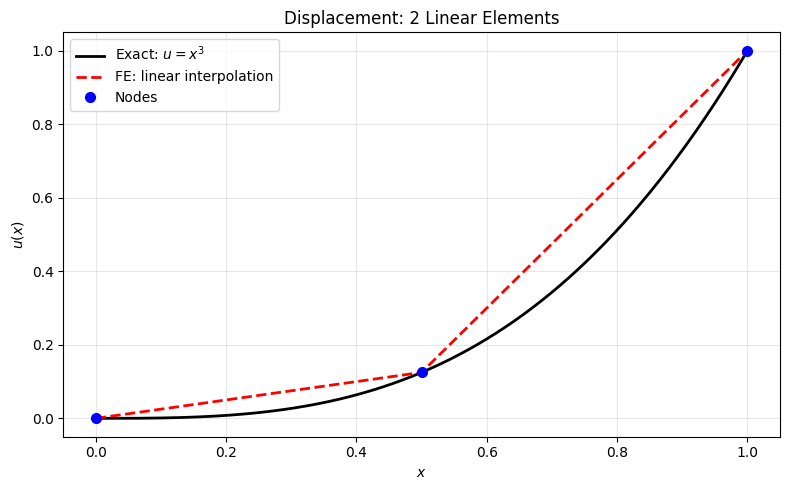

In [4]:
#Problem 3(a)
n_elements = 2

# Calculate FE solution
x_nodes, d, x_fe, u_fe, x_strain, strain_fe = fem_solution(n_elements)

# Print mesh information
print("Number of elements:", n_elements)
print("Nodal coordinates:")
print(x_nodes)

print("\nNodal displacements:")
print(d)

# Exact solution
x_exact_plot = np.linspace(0, 1, 500)
u_exact_plot = u_exact(x_exact_plot)

# Plot displacement
plt.figure(figsize=(8, 5))

plt.plot(
    x_exact_plot,
    u_exact_plot,
    'k-',
    linewidth=2,
    label='Exact: $u=x^3$'
)

plt.plot(
    x_fe,
    u_fe,
    'r--',
    linewidth=2,
    label='FE: linear interpolation'
)

plt.plot(
    x_nodes,
    d,
    'bo',
    markersize=7,
    label='Nodes'
)

plt.xlabel('$x$')
plt.ylabel('$u(x)$')
plt.title('Displacement: 2 Linear Elements')
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()


Element strains for 2 elements:

Element 1:
  x = [0.0, 0.5]
  h = 0.5
  d^e = [0.    0.125]
  B = [-2.  2.]
  strain = 0.25

Element 2:
  x = [0.5, 1.0]
  h = 0.5
  d^e = [0.125 1.   ]
  B = [-2.  2.]
  strain = 1.75



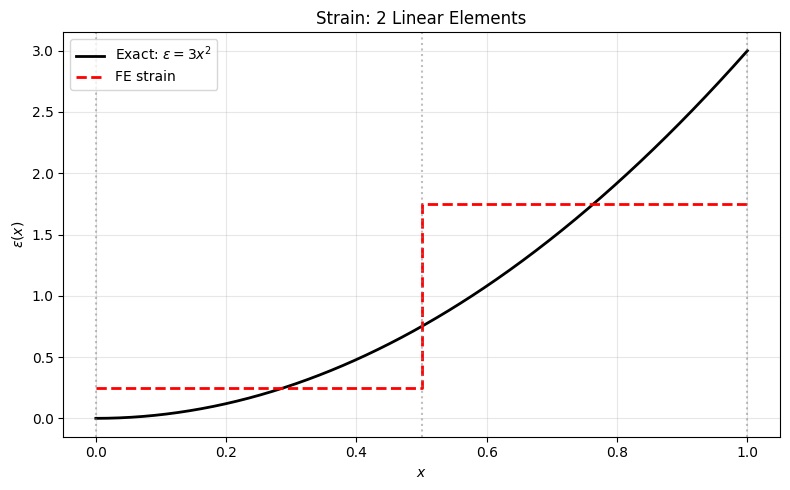

In [6]:
#Problem 3(b)

# Exact strain
strain_exact_plot = strain_exact(x_exact_plot)

print("Element strains for 2 elements:\n")

for e in range(n_elements):

    x1 = x_nodes[e]
    x2 = x_nodes[e+1]

    h = x2 - x1

    de = np.array([d[e], d[e+1]])

    # B matrix
    B = np.array([-1/h, 1/h])

    # Strain
    epsilon = B @ de

    print(f"Element {e+1}:")
    print(f"  x = [{x1}, {x2}]")
    print(f"  h = {h}")
    print(f"  d^e = {de}")
    print(f"  B = {B}")
    print(f"  strain = {epsilon}")
    print()

plt.figure(figsize=(8, 5))

# Exact strain
plt.plot(
    x_exact_plot,
    strain_exact_plot,
    'k-',
    linewidth=2,
    label='Exact: $\\epsilon=3x^2$'
)

# FE strain
plt.plot(
    x_strain,
    strain_fe,
    'r--',
    linewidth=2,
    drawstyle='steps-post',
    label='FE strain'
)

# Element boundaries
for x in x_nodes:
    plt.axvline(x, color='gray', linestyle=':', alpha=0.5)

plt.xlabel('$x$')
plt.ylabel('$\\epsilon(x)$')
plt.title('Strain: 2 Linear Elements')
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()


Number of elements: 4
Nodal coordinates:
[0.   0.25 0.5  0.75 1.  ]

Nodal displacements:
[0.       0.015625 0.125    0.421875 1.      ]


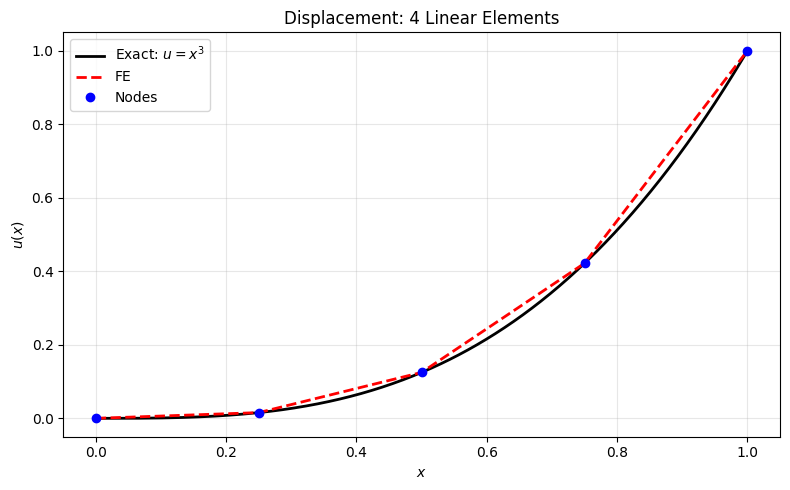

In [7]:
#Problem 3(c) -- 4 elements displacements
n_elements = 4

x_nodes, d, x_fe, u_fe, x_strain, strain_fe = fem_solution(n_elements)

print("Number of elements:", n_elements)
print("Nodal coordinates:")
print(x_nodes)

print("\nNodal displacements:")
print(d)

plt.figure(figsize=(8, 5))

plt.plot(
    x_exact_plot,
    u_exact_plot,
    'k-',
    linewidth=2,
    label='Exact: $u=x^3$'
)

plt.plot(
    x_fe,
    u_fe,
    'r--',
    linewidth=2,
    label='FE'
)

plt.plot(
    x_nodes,
    d,
    'bo',
    markersize=6,
    label='Nodes'
)

plt.xlabel('$x$')
plt.ylabel('$u(x)$')
plt.title('Displacement: 4 Linear Elements')
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()


Element strains for 4 elements:

Element 1:
  x = [0.0, 0.25]
  h = 0.25
  d^e = [0.       0.015625]
  B = [-4.  4.]
  strain = 0.0625

Element 2:
  x = [0.25, 0.5]
  h = 0.25
  d^e = [0.015625 0.125   ]
  B = [-4.  4.]
  strain = 0.4375

Element 3:
  x = [0.5, 0.75]
  h = 0.25
  d^e = [0.125    0.421875]
  B = [-4.  4.]
  strain = 1.1875

Element 4:
  x = [0.75, 1.0]
  h = 0.25
  d^e = [0.421875 1.      ]
  B = [-4.  4.]
  strain = 2.3125



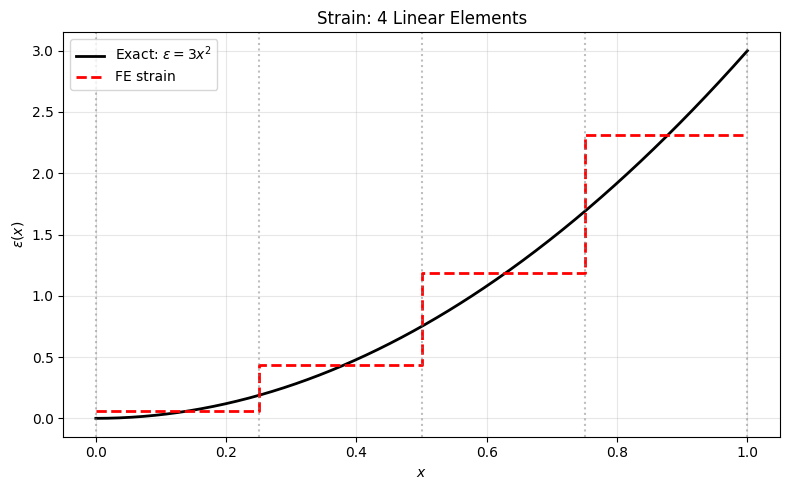

In [10]:
#4 element strain

# Exact strain
strain_exact_plot = strain_exact(x_exact_plot)

print("Element strains for 4 elements:\n")

for e in range(n_elements):

    x1 = x_nodes[e]
    x2 = x_nodes[e+1]

    h = x2 - x1

    de = np.array([d[e], d[e+1]])

    # B matrix
    B = np.array([-1/h, 1/h])

    # Strain
    epsilon = B @ de

    print(f"Element {e+1}:")
    print(f"  x = [{x1}, {x2}]")
    print(f"  h = {h}")
    print(f"  d^e = {de}")
    print(f"  B = {B}")
    print(f"  strain = {epsilon}")
    print()

plt.figure(figsize=(8, 5))

# Exact strain
plt.plot(
    x_exact_plot,
    strain_exact_plot,
    'k-',
    linewidth=2,
    label='Exact: $\\epsilon=3x^2$'
)

# FE strain
plt.plot(
    x_strain,
    strain_fe,
    'r--',
    linewidth=2,
    drawstyle='steps-post',
    label='FE strain'
)

# Element boundaries
for x in x_nodes:
    plt.axvline(x, color='gray', linestyle=':', alpha=0.5)

plt.xlabel('$x$')
plt.ylabel('$\\epsilon(x)$')
plt.title('Strain: 4 Linear Elements')
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()


Number of elements: 8
Nodal coordinates:
[0.    0.125 0.25  0.375 0.5   0.625 0.75  0.875 1.   ]

Nodal displacements:
[0.         0.00195312 0.015625   0.05273438 0.125      0.24414062
 0.421875   0.66992188 1.        ]


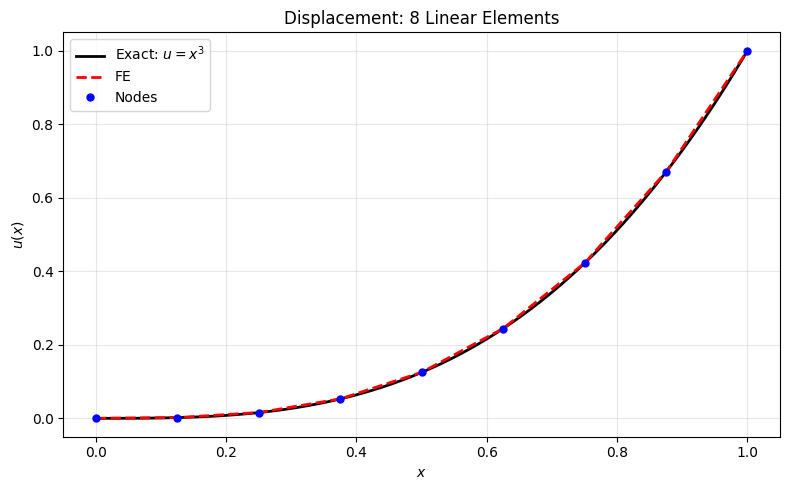

In [11]:
# Problem 3(c) -- 8 element displacement
n_elements = 8

x_nodes, d, x_fe, u_fe, x_strain, strain_fe = fem_solution(n_elements)

print("Number of elements:", n_elements)
print("Nodal coordinates:")
print(x_nodes)

print("\nNodal displacements:")
print(d)

plt.figure(figsize=(8, 5))

plt.plot(
    x_exact_plot,
    u_exact_plot,
    'k-',
    linewidth=2,
    label='Exact: $u=x^3$'
)

plt.plot(
    x_fe,
    u_fe,
    'r--',
    linewidth=2,
    label='FE'
)

plt.plot(
    x_nodes,
    d,
    'bo',
    markersize=5,
    label='Nodes'
)

plt.xlabel('$x$')
plt.ylabel('$u(x)$')
plt.title('Displacement: 8 Linear Elements')
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()


Element strains for 8 elements:

Element 1:
  x = [0.0, 0.125]
  h = 0.125
  d^e = [0.         0.00195312]
  B = [-8.  8.]
  strain = 0.015625

Element 2:
  x = [0.125, 0.25]
  h = 0.125
  d^e = [0.00195312 0.015625  ]
  B = [-8.  8.]
  strain = 0.109375

Element 3:
  x = [0.25, 0.375]
  h = 0.125
  d^e = [0.015625   0.05273438]
  B = [-8.  8.]
  strain = 0.296875

Element 4:
  x = [0.375, 0.5]
  h = 0.125
  d^e = [0.05273438 0.125     ]
  B = [-8.  8.]
  strain = 0.578125

Element 5:
  x = [0.5, 0.625]
  h = 0.125
  d^e = [0.125      0.24414062]
  B = [-8.  8.]
  strain = 0.953125

Element 6:
  x = [0.625, 0.75]
  h = 0.125
  d^e = [0.24414062 0.421875  ]
  B = [-8.  8.]
  strain = 1.421875

Element 7:
  x = [0.75, 0.875]
  h = 0.125
  d^e = [0.421875   0.66992188]
  B = [-8.  8.]
  strain = 1.984375

Element 8:
  x = [0.875, 1.0]
  h = 0.125
  d^e = [0.66992188 1.        ]
  B = [-8.  8.]
  strain = 2.640625



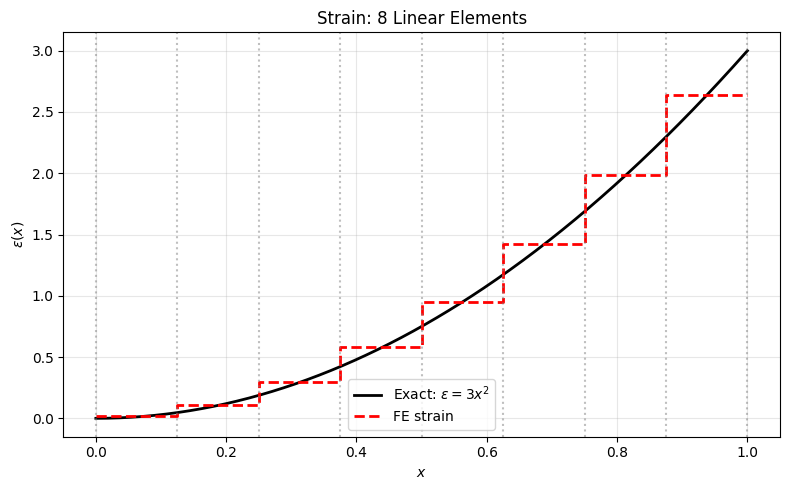

In [12]:
#8 element strain

# Exact strain
strain_exact_plot = strain_exact(x_exact_plot)

print("Element strains for 8 elements:\n")

for e in range(n_elements):

    x1 = x_nodes[e]
    x2 = x_nodes[e+1]

    h = x2 - x1

    de = np.array([d[e], d[e+1]])

    # B matrix
    B = np.array([-1/h, 1/h])

    # Strain
    epsilon = B @ de

    print(f"Element {e+1}:")
    print(f"  x = [{x1}, {x2}]")
    print(f"  h = {h}")
    print(f"  d^e = {de}")
    print(f"  B = {B}")
    print(f"  strain = {epsilon}")
    print()

plt.figure(figsize=(8, 5))

# Exact strain
plt.plot(
    x_exact_plot,
    strain_exact_plot,
    'k-',
    linewidth=2,
    label='Exact: $\\epsilon=3x^2$'
)

# FE strain
plt.plot(
    x_strain,
    strain_fe,
    'r--',
    linewidth=2,
    drawstyle='steps-post',
    label='FE strain'
)

# Element boundaries
for x in x_nodes:
    plt.axvline(x, color='gray', linestyle=':', alpha=0.5)

plt.xlabel('$x$')
plt.ylabel('$\\epsilon(x)$')
plt.title('Strain: 8 Linear Elements')
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()
